# Learning different Optimizers

# **SGD with Momentum**

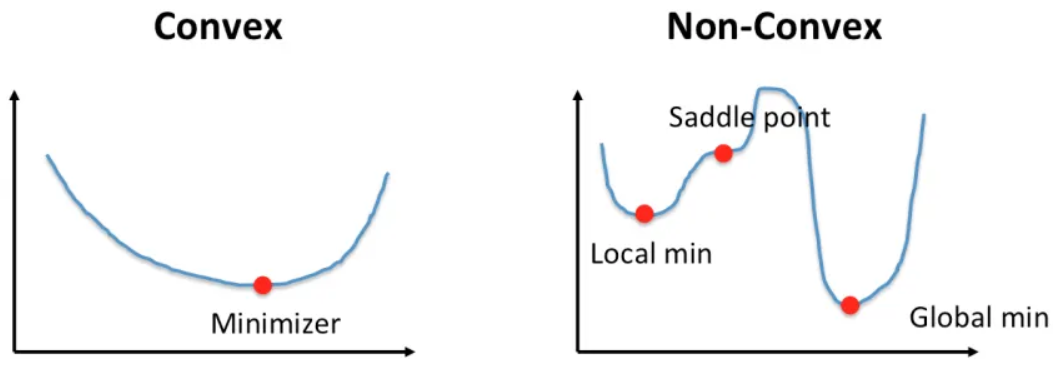

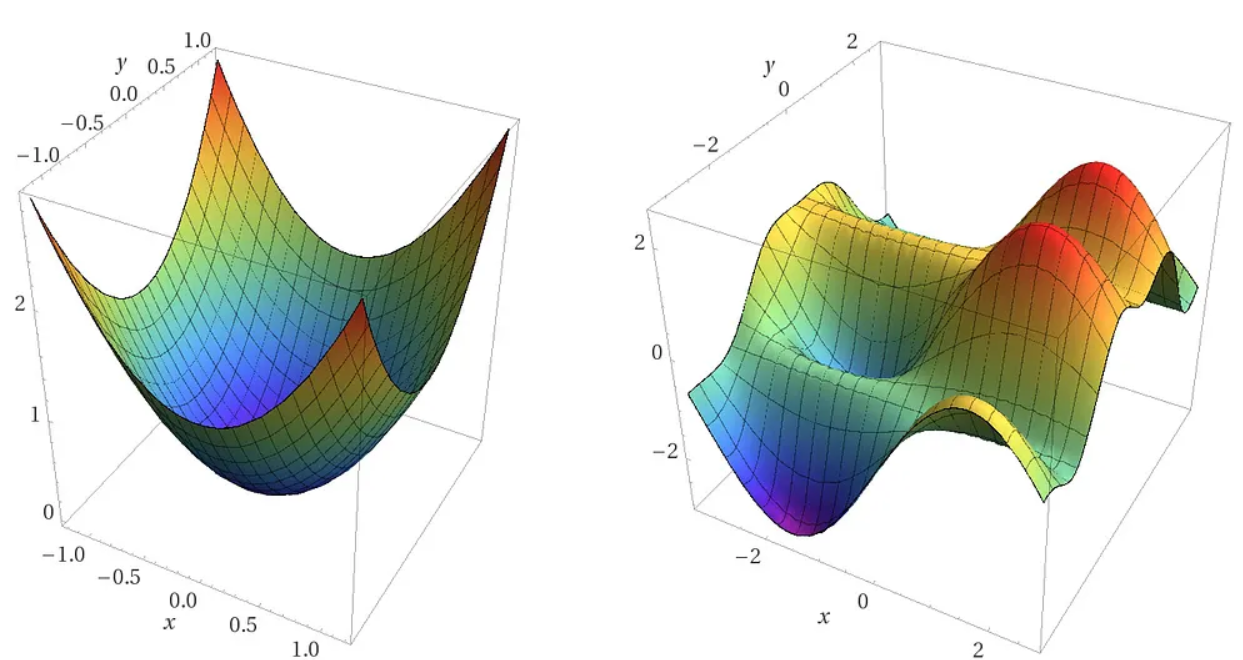

**THE FIRST IMAGE HERE IS WITH ONE GLOBAL MINIMA FOR SGD, AND SECOND IMAGE IS WITH MULTIPLE GLOBAL MINIMA FOR SGD WITH MOMENTUM**

**SGD with momentum is like a ball that stops at the global minima (minimum point).**<br>
Stochastic Gradient Descent (SGD) with Momentum is an advanced optimization algorithm that adds a **"velocity"** term to standard SGD. It builds up a memory of past gradient directions using an Exponentially Weighted Moving Average (EWMA), mimicking a heavy ball rolling down a hill.


## 1. The Core Intuition: The Heavy Ball Analogy

Imagine a long, narrow U-shaped valley where the lowest point (the global minimum loss) is at the far end:

* **Standard SGD** is like a hiker who only looks at the ground under their feet. Because the side walls are steep, the hiker takes a step down, overshoots, ends up on the opposite steep wall, and is forced to step back. They waste time bouncing back and forth wildly (oscillating) between the walls, making very slow progress toward the exit.
* **SGD with Momentum** is like a **heavy bowling ball**. When dropped, it starts rolling. It might try to bounce up the side walls, but because of its mass and inertia, the side-to-side forces cancel out. The ball builds up speed along the main valley floor, accelerating toward the exit.


## 2. The Mathematics: How EWMA Powers Momentum

Momentum works by calculating a running average of all past gradients using EWMA, and using that average to update the weights.

### **The Standard SGD Equation (No Memory)**
$$w_{t+1} = w_t - \eta \cdot g_t$$

### **The SGD with Momentum Equation**
At each step $t$, we calculate a velocity vector ($v_t$) and use it to update our weights ($w_t$):

1. **Calculate Velocity (EWMA of Gradients):**
   $$v_t = \beta \cdot v_{t-1} + (1 - \beta) \cdot g_t$$
2. **Update the Weights:**
   $$w_{t+1} = w_t - \eta \cdot v_t$$

### **Symbol Legend:**
* **$w_t$:** The weight values at the current step.
* **$g_t$:** The raw gradient calculated from the current batch.
* **$v_t$:** The accumulated velocity (momentum) at the current step.
* **$v_{t-1}$:** The velocity from the previous step.
* **$\eta$ (Eta):** The learning rate (step size).
* **$\beta$ (Beta):** The momentum coefficient (friction). Usually fixed at **`0.9`** (which averages the gradients over approximately the last $\frac{1}{1-0.9} = 10$ steps).


## 3. How the Ball Settles: The "Marble in a Bowl" Concept

Because the optimizer has momentum, it does not freeze the instant it touches the lowest point (minimum loss). Instead, it behaves like a physical marble dropped into a smooth bowl:

```text
       Start
         \
          \             Overshoot
           \               /
            \             /
             v           v
              \  .---.  /
               \/     \/
                ' . . '
                   ^
              Settles here
```

1. **The Overshoot:** The ball sprints down the hill. When it hits the global minimum, its accumulated speed carries it right past the bottom, climbing up the opposite slope.
2. **The Wobble (Oscillation):** The gravity of the opposite slope slows it down to a stop. The ball turns around, rolls back down, shoots past the bottom again (climbing a shorter distance on the original side), and continues to wobble back and forth.
3. **Settling Down:** As the gradients become tiny near the bottom, the friction factor ($\beta$) dampens the velocity, allowing the ball to make smaller and smaller swings until it rests precisely at the global minimum.

*Note: If your learning rate ($\eta$) is too high or momentum ($\beta$) is too strong, the ball might gain too much speed, overshoot permanently, and fly out of the bowl (causing the loss to explode).*


## 4. Pros & Cons

### **Pros**
* **Dampens Oscillations:** Successfully filters out noisy, zig-zagging gradient steps, smoothing the path to the minimum.
* **Faster Convergence:** Accelerates training by taking progressively larger steps in consistent directions.
* **Escapes Saddle Points:** If the optimizer encounters a flat plateau where the gradient is zero, its accumulated velocity ($v_{t-1}$) carries it right across the flat zone.

### **Cons**
* **Overshooting:** Can roll past the ideal minimum, requiring a brief "wobbling" phase to settle down at the end of training.
* **Extra Parameter:** Adds a new hyperparameter ($\beta$) that must be set manually.
* **No Individual Weight Scaling:** It applies the same momentum multiplier to all weights equally, regardless of how often or rarely a specific weight is updated.


## 5. Keras Code Implementation

```python
from tensorflow import keras

# Define the SGD optimizer with 0.9 momentum
opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

# Compile your model
model.compile(optimizer=opt, loss='mean_squared_error')
```

---

# The Mathematics of SGD with Momentum

Stochastic Gradient Descent (SGD) with Momentum uses an Exponentially Weighted Moving Average (EWMA) to accumulate past gradients. This acting "velocity" accelerates the model along consistent directions and dampens noisy oscillations.

## 1. Comparing the Equations

To understand the change, look at how the update step evolves from standard SGD to SGD with Momentum.

### Standard SGD Equation (No Memory)

$$w_{t+1} = w_t - \eta \cdot g_t$$

### SGD with Momentum Equations

Momentum splits the update step into two parts: calculating the velocity (which acts as our EWMA gradient memory) and updating the weights.

$$v_t = \beta \cdot v_{t-1} + (1 - \beta) \cdot g_t$$

$$w_{t+1} = w_t - \eta \cdot v_t$$

## 2. Symbol Legend

* **$w_t$:** The weight value at the current training step $t$.
* **$w_{t+1}$:** The updated weight value for the next step.
* **$g_t$:** The raw gradient calculated at the current step ($\nabla L(w_t)$).
* **$v_t$:** The current velocity (momentum) vector.
* **$v_{t-1}$:** The velocity from the previous training step.
* **$\beta$ (Beta):** The momentum coefficient (friction). A fixed value between $0$ and $1$ (usually set to `0.9`). It determines how much of the past velocity we retain.
* **$\eta$ (Eta):** The learning rate (step size).

## 3. Mathematical Intuition: How Momentum Dampens Oscillations

To see the math in action, imagine we are optimizing a 2D loss function where:
* The **Y-axis** is a steep ravine. The gradients bounce back and forth between positive and negative values: $+10, -10, +10, -10$.
* The **X-axis** is a gentle slope pointing toward the minimum. The gradients are small but consistent: $+1, +1, +1, +1$.

Let's calculate the velocity ($v_t$) along both axes over 3 steps using $\beta = 0.9$:

### Along the Steep Y-Axis (Oscillating Gradients)
* **Step 1 ($g_1 = +10$):**  
  $$v_1 = 0.9 \cdot (0) + 0.1 \cdot (10) = \mathbf{+1.0}$$
* **Step 2 ($g_2 = -10$):**  
  $$v_2 = 0.9 \cdot (1.0) + 0.1 \cdot (-10) = 0.9 - 1.0 = \mathbf{-0.1}$$
* **Step 3 ($g_3 = +10$):**  
  $$v_3 = 0.9 \cdot (-0.1) + 0.1 \cdot (10) = -0.09 + 1.0 = \mathbf{+0.91}$$

The velocity along the Y-axis remains small (between $-0.1$ and $+1.0$), successfully preventing the model from bouncing wildly up and down the ravine walls.

### Along the Gentle X-Axis (Consistent Gradients)
* **Step 1 ($g_1 = +1$):**  
  $$v_1 = 0.9 \cdot (0) + 0.1 \cdot (1) = \mathbf{+0.1}$$
* **Step 2 ($g_2 = +1$):**  
  $$v_2 = 0.9 \cdot (0.1) + 0.1 \cdot (1) = 0.09 + 0.1 = \mathbf{+0.19}$$
* **Step 3 ($g_3 = +1$):**  
  $$v_3 = 0.9 \cdot (0.19) + 0.1 \cdot (1) = 0.171 + 0.1 = \mathbf{+0.271}$$

Because the gradient is consistently positive, the velocity values grow larger at each step. This allows the model to accelerate quickly along the X-axis toward the global minimum.

## 4. Alternative Formulation (Physical Velocity)

In many deep learning libraries (like PyTorch and Keras), the learning rate is multiplied inside the velocity step rather than the update step. While written slightly differently, the mathematical behavior is identical:

$$v_t = \beta \cdot v_{t-1} + \eta \cdot g_t$$

$$w_{t+1} = w_t - v_t$$

Here, $\beta$ acts as physical friction (damping the speed of the rolling ball), while the learning rate $\eta$ acts as the gravity pushing the ball down the slope.

---

# **The Limitations of Plain SGD: Why We Upgraded to Momentum ???**

Stochastic Gradient Descent (SGD) in its purest form updates weights using only the gradient calculated at the current step. While simple, this "zero-memory" approach has severe limitations when training deep neural networks.


## 1. The "Ravine" Problem (Wild Oscillations)

In deep learning, loss landscapes are rarely symmetrical **(there can me multiple minima)**. They are often shaped like narrow ravines—where the slopes are incredibly steep on the sides, but very gentle along the floor (the direction leading to the minimum).

* **The Plain SGD Flaw:** Because plain SGD only looks at the gradient of its current position, it gets dominated by the steep side-slopes. It takes a massive step down one wall, overshoots the valley floor, lands high up on the opposite wall, and has to bounce back. It spends most of its computation time oscillating side-to-side, making almost zero progress along the floor.
* **The Momentum Fix:** Momentum keeps a running average of the steps. The side-to-side bounces (which alternate directions, e.g., $+10$ and $-10$) cancel out, while the forward steps along the floor accumulate, leading to a smooth path.


## 2. The Saddle Point Trap (Getting Stuck on Plateaus)

In high-dimensional neural networks, the biggest obstacle to training is **saddle points**—flat regions where the slope is zero in some directions, but slants down in others.

* **The Plain SGD Flaw:** When plain SGD rolls into the middle of a flat plateau, the gradient drops to zero ($g_t = 0$). Since plain SGD calculates its step size as $\text{Step} = \text{Learning Rate} \times \text{Gradient}$, its step size instantly becomes zero. It stops moving and gets permanently trapped.
* **The Momentum Fix:** Because momentum carries a memory of the velocity from previous steps, the optimizer is able to "glide" right across the flat plateau using its accumulated inertia until it finds the downward slope on the other side.


## 3. The Constant Speed Limit (No Acceleration)

Plain SGD operates step-by-step with no awareness of the surrounding landscape trends.

* **The Plain SGD Flaw:** If the optimizer is on a long, smooth, consistent slope pointing directly to the minimum, plain SGD will walk down it at the same slow pace. It has no way to recognize that it has been moving in the exact same direction for dozens of steps.
* **The Momentum Fix:** By summing up gradients pointing in the same direction, momentum acts like a snowball rolling down a hill. It continuously accelerates, speeding up training times significantly.


## 4. Extreme Sensitivity to Mini-Batch Noise

Stochastic Gradient Descent calculates gradients using a small subset of the data (a mini-batch).

* **The Plain SGD Flaw:** If a single mini-batch contains noisy or anomalous data, plain SGD will immediately take a sharp, erratic turn in the wrong direction.
* **The Momentum Fix:** The EWMA acts as a low-pass filter. A single noisy gradient is heavily diluted by the historical average of the past steps, keeping the optimizer on a stable trajectory.


## Summary comparison

| Scenario | Plain SGD | SGD with Momentum |
| :--- | :--- | :--- |
| **Steep Ravine** | Bounces wildly side-to-side; slow forward progress | Dampens side-to-side bounces; slides smoothly forward |
| **Saddle Point ($g_t = 0$)** | Stops immediately and gets stuck | Glides through using accumulated velocity |
| **Consistent Slope** | Moves at a slow, constant speed | Accelerates, reaching the bottom faster |
| **Noisy Mini-Batch** | Reacts instantly and erratically | Filters out the noise, maintaining a stable direction |